In [1]:
import numpy as np
from gurobipy import GRB, Model
from matplotlib import pyplot as plt
import pandas as pd

## Daten

In [2]:
data = pd.read_excel("data.xlsx")
data.head()

,x,y
0,8.704628,4.623982
1,7.218730,2.282839
2,9.103622,3.886074
3,3.998943,1.628829
4,8.902633,4.664581


In [10]:
x = data['x']
y = data['y']
data_size = x.shape[0]
X = np.append([x],[np.ones(data_size)], axis=0).transpose()

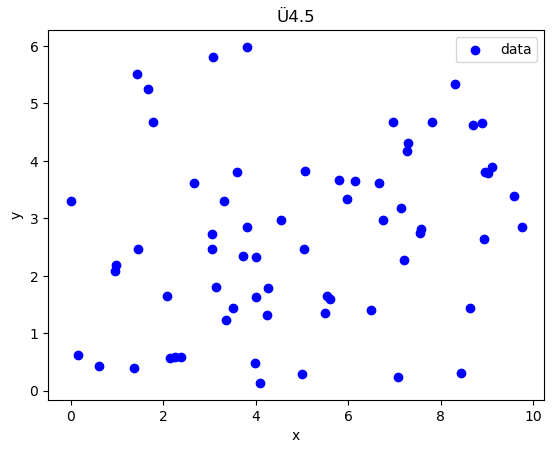

In [7]:
plt.scatter(x, y, color="blue", label='data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ü4.5')
plt.legend()
plt.show()

## Optimierungsmodel

In [4]:
m = Model('Approximation')

# Variablen
a = m.addVar(vtype = GRB.CONTINUOUS, name="a", lb=-GRB.INFINITY)
b = m.addVar(vtype = GRB.CONTINUOUS, name="b", lb=-GRB.INFINITY)
beta = np.array([a,b])
m.update()

# Zielfunktion
m.setObjective((X@beta-y)@(X@beta-y), GRB.MINIMIZE)
m.update()
m.optimize()

print("\n\n")
print(f"Wir erhalten beta = {[beta[i].x for i in range(2)]}")

Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-12
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 0 rows, 2 columns and 0 nonzeros
Model fingerprint: 0x9622182a
Model has 3 quadratic objective terms
Coefficient statistics:
  Matrix range     [0e+00, 0e+00]
  Objective range  [3e+02, 2e+03]
  QObjective range [1e+02, 4e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [0e+00, 0e+00]
Presolve time: 0.02s
Presolved: 0 rows, 2 columns, 0 nonzeros
Presolved model has 3 quadratic objective terms
Ordering time: 0.00s

Barrier statistics:
 Free vars  : 3
 AA' NZ     : 0.000e+00
 Factor NZ  : 1.000e+00
 Factor Ops : 1.000e+00 (less than 1 second per iteration)
 Threads    : 1

                  Objective                Residual
It

## Plot

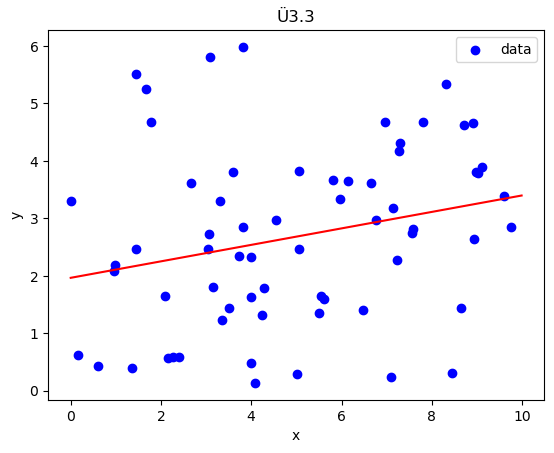

In [5]:
# plotdata
beta_sol = np.array(m.x)
x_plot = np.arange(0,10,0.01)
y_reg = beta_sol[0]*x_plot+beta_sol[1]


plt.scatter(x, y, color="blue", label='data')
plt.plot(x_plot,y_reg, color="red")

plt.xlabel('x')
plt.ylabel('y')
plt.title('Ü4.5')
plt.legend()
plt.show()